# Human Evaluation — Survey Analysis

Analyses annotator responses for the human evaluation study comparing **real** vs **synthetic** Dutch housing comments.  
Metrics evaluated: **Fluency**, **Relevance**, **Humanness** (1–5 Likert scale).

Pipeline:
1. Parse Google Form CSV exports
2. Merge with master to recover condition labels
3. Inter-annotator agreement (Quadratic Weighted Cohen's κ)
4. Average scores per item
5. Mann-Whitney U test (Real vs Synthetic)
6. Boxplots
7. Save results

## Imports & Config

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import cohen_kappa_score
from scipy.stats import mannwhitneyu

results_base = r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\human_evaluation\results"
subsets_base = r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\human_evaluation\subsets"
metrics = ['fluency', 'relevance', 'humanness']

# Circular sliding window overlap pairs (Ann 7 → Ann 1 closes the loop)
overlap_pairs = [(1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,1)]

## Step 1 — Parse Google Form Responses

In [2]:
import json

def parse_annotator_response(csv_path, annotator_id, subset_path=None):
    """
    Parse Google Form CSV export.
    Columns are repeated question text with pandas suffixes (.1, .2, ... .19).
    Groups of 3 columns per item: fluency, relevance, humanness.
    item_order is looked up from the annotator subset file to recover pair_id.
    subset_path lets an annotator's mapping come from a different file than the
    default (used for Ann 1, whose current unified submission is defined by
    annotator_01_new.json rather than the pre-redesign annotator_01.csv).
    """
    df  = pd.read_csv(csv_path)
    row = df.iloc[0].values  # one submission per annotator

    if subset_path is None:
        subset_path = f"{subsets_base}\\annotator_{annotator_id:02d}.csv"

    if subset_path.endswith('.json'):
        with open(subset_path, encoding='utf-8') as f:
            subset = pd.DataFrame(json.load(f))
    else:
        subset = pd.read_csv(subset_path)

    order_to_pair = dict(zip(subset['item_order'], subset['pair_id']))
    n_items = len(subset)

    records = []
    for item_order in range(1, n_items + 1):
        pair_id  = order_to_pair[item_order]
        base_idx = 1 + (item_order - 1) * 3   # skip Timestamp at index 0
        records.append({
            'annotator_id': annotator_id,
            'pair_id':      pair_id,
            'fluency':      int(row[base_idx]),
            'relevance':    int(row[base_idx + 1]),
            'humanness':    int(row[base_idx + 2]),
        })

    return pd.DataFrame(records)


# ── Load all 7 annotators ──
all_responses = []

for ann_id in range(1, 8):
    if ann_id == 1:
        # Ann 1's subset was redesigned mid-study to close the circular loop
        # (pair (7,1) needs a shared block with Ann 7). The current unified
        # 20-item submission (annotator_01_responses.csv) maps via
        # annotator_01_new.json, not the original pre-redesign annotator_01.csv.
        ann_df = parse_annotator_response(
            csv_path=f"{results_base}\\annotator_01_responses.csv",
            annotator_id=1,
            subset_path=f"{subsets_base}\\annotator_01_new.json",
        )
    else:
        path   = f"{results_base}\\annotator_{ann_id:02d}_responses.csv"
        ann_df = parse_annotator_response(path, ann_id)

    all_responses.append(ann_df)
    print(f"Annotator {ann_id}: {len(ann_df)} items parsed")

responses = pd.concat(all_responses, ignore_index=True)
print(f"\nTotal responses: {len(responses)} (expect 140)")

Annotator 1: 20 items parsed
Annotator 2: 20 items parsed
Annotator 3: 20 items parsed
Annotator 4: 20 items parsed
Annotator 5: 20 items parsed
Annotator 6: 20 items parsed
Annotator 7: 20 items parsed

Total responses: 140 (expect 140)


In [3]:
responses

,annotator_id,pair_id,fluency,relevance,humanness
0,1,79,5,5,4
1,1,76,3,5,3
2,1,40,5,5,3
3,1,77,2,3,4
4,1,80,3,3,5
...,...,...,...,...,...
135,7,37,5,5,5
136,7,74,5,5,5
137,7,72,4,5,5
138,7,33,5,5,5


## Step 2 — Merge with Master to Get Condition Labels

In [4]:
master = pd.read_csv(f"{subsets_base}\\master_with_conditions.csv")

# Merge on pair_id only — condition/item_id/post/comment are properties of the
# pair, not the annotator. Ann 1's new items (pair_ids from Ann 7's block) exist
# in master under annotator_id=7, so joining on annotator_id+pair_id would miss them.
pair_info = (master[['pair_id', 'condition', 'item_id', 'post', 'comment']]
             .drop_duplicates('pair_id'))

results = responses.merge(pair_info, on='pair_id', how='left')

print(f"Null conditions: {results['condition'].isna().sum()} (expect 0)")
print(f"Condition counts:\n{results['condition'].value_counts()}")

Null conditions: 0 (expect 0)
Condition counts:
condition
synthetic    70
real         70
Name: count, dtype: int64


In [5]:
results

,annotator_id,pair_id,fluency,relevance,humanness,condition,item_id,post,comment
0,1,79,5,5,4,synthetic,78,Ook deze week zijn werklieden volop bezig met ...,Hoe zit t nou met de woningen langs de H.H. te...
1,1,76,3,5,3,synthetic,72,Sla de krant open en je leest over de energier...,Huurverhoging van woningen met slechte isolati...
2,1,40,5,5,3,real,79,De laatste gratis energiebespaarpakketten t.w....,"<ORG> jammer , dat er op dit vlak onderscheid..."
3,1,77,2,3,4,synthetic,74,17.000 bewoners krijgen een uitnodiging om dee...,Ik heb wel een email gehad maar ik krijg hem n...
4,1,80,3,3,5,synthetic,80,Op donderdag 18 januari zijn ons kantoor en de...,Nou jullie zouden mij een brief kunnen sturen ...
...,...,...,...,...,...,...,...,...,...
135,7,37,5,5,5,real,73,De 188 huurappartementen aan de Roelantlaan en...,Ik hoop van harte dat jullie beter met deze me...
136,7,74,5,5,5,synthetic,68,Wij presteren goed! Dat blijkt uit cijfers uit...,Met jullie besparing in onderhoud kun je ook w...
137,7,72,4,5,5,synthetic,64,"Duurzaamheid | Morgen, vrijdag 11 februari, is...",Zou wel fijn zijn als jullie zelf een warm tru...
138,7,33,5,5,5,real,65,In deze korte film zie je hoe <ORG> 499 huizen...,nou dat mogen jullie bij de bestaande panden o...


## Step 3 — Inter-Annotator Agreement (Quadratic Weighted Cohen's κ)

κ is computed only on shared items between each consecutive annotator pair (10 overlapping items per pair).

In [6]:
print("=== INTER-ANNOTATOR AGREEMENT (Quadratic Weighted Cohen's κ) ===")

kappa_records = []

for ann_a, ann_b in overlap_pairs:

    items_a = set(results[results['annotator_id'] == ann_a]['item_id'])
    items_b = set(results[results['annotator_id'] == ann_b]['item_id'])
    shared  = items_a & items_b

    print(f"\n  Pair ({ann_a},{ann_b}) — {len(shared)} shared items:")

    if len(shared) == 0:
        print(f"    WARNING: no shared items found!")
        continue

    scores_a = (results[(results['annotator_id'] == ann_a) &
                        (results['item_id'].isin(shared))]
                .sort_values('item_id'))

    scores_b = (results[(results['annotator_id'] == ann_b) &
                        (results['item_id'].isin(shared))]
                .sort_values('item_id'))

    for metric in metrics:
        kappa = cohen_kappa_score(
            scores_a[metric].values,
            scores_b[metric].values,
            weights='quadratic'
        )
        kappa_records.append({
            'pair':   f"({ann_a},{ann_b})",
            'metric': metric,
            'kappa':  round(kappa, 3)
        })
        print(f"    {metric:>10}: κ = {kappa:.3f}")

kappa_df = pd.DataFrame(kappa_records)

print(f"\nMean κ per metric (across all overlap pairs):")
for metric, k in kappa_df.groupby('metric')['kappa'].mean().items():
    interpretation = (
        'slight'          if k < 0.20 else
        'fair'            if k < 0.40 else
        'moderate'        if k < 0.60 else
        'substantial'     if k < 0.80 else
        'almost perfect'
    )
    print(f"  {metric:>10}: κ = {k:.3f} ({interpretation})")

print(f"\nOverall mean κ: {kappa_df['kappa'].mean():.3f}")

=== INTER-ANNOTATOR AGREEMENT (Quadratic Weighted Cohen's κ) ===

  Pair (1,2) — 10 shared items:
       fluency: κ = 0.194
     relevance: κ = 0.565
     humanness: κ = -0.400

  Pair (2,3) — 10 shared items:
       fluency: κ = 0.321
     relevance: κ = 0.862
     humanness: κ = 0.188

  Pair (3,4) — 10 shared items:
       fluency: κ = 0.517
     relevance: κ = -0.048
     humanness: κ = 0.696

  Pair (4,5) — 10 shared items:
       fluency: κ = 0.328
     relevance: κ = 0.343
     humanness: κ = 0.407

  Pair (5,6) — 10 shared items:
       fluency: κ = 0.455
     relevance: κ = 0.419
     humanness: κ = -0.143

  Pair (6,7) — 10 shared items:
       fluency: κ = 0.200
     relevance: κ = -0.069
     humanness: κ = 0.154

  Pair (7,1) — 10 shared items:
       fluency: κ = -0.011
     relevance: κ = -0.391
     humanness: κ = 0.043

Mean κ per metric (across all overlap pairs):
     fluency: κ = 0.286 (fair)
   humanness: κ = 0.135 (slight)
   relevance: κ = 0.240 (fair)

Overall m

## Step 3b — Krippendorff's Alpha

Pairwise Cohen's κ computed on 10 items per pair is unreliable (Gwet, 2014; Artstein & Poesio, 2008 recommend ≥ 30 items).  
Krippendorff's α is the standard alternative for this design: it handles missing data natively, uses all 7 annotators simultaneously, and applies an ordinal distance metric appropriate for 1–5 Likert scales.

In [7]:
try:
    import krippendorff
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'krippendorff'])
    import krippendorff

# ── Build reliability data matrix: shape (n_annotators × n_items) ─────────────
# Rows = annotators (1–7), columns = item_ids present in results, NaN = not rated.
# After circular redesign, item_ids 1–10 are unrated and absent from results.

rated_item_ids  = sorted(results['item_id'].unique())   # item_ids 11–80
item_id_to_col  = {iid: j for j, iid in enumerate(rated_item_ids)}
n_items         = len(rated_item_ids)
n_ann           = 7

print("=== KRIPPENDORFF'S ALPHA (Ordinal) ===\n")
print(f"Reliability matrix: {n_ann} annotators × {n_items} items")
print(f"Items covered: {rated_item_ids[0]}–{rated_item_ids[-1]}  "
      f"(item_ids 1–10 excluded — unrated after circular redesign)\n")

alpha_records = []

for metric in metrics:
    matrix = np.full((n_ann, n_items), np.nan)

    for ann_id in range(1, n_ann + 1):
        ann_rows = results[results['annotator_id'] == ann_id][['item_id', metric]]
        for _, row in ann_rows.iterrows():
            matrix[ann_id - 1, item_id_to_col[int(row['item_id'])]] = row[metric]

    alpha = krippendorff.alpha(reliability_data=matrix, level_of_measurement='ordinal')

    interpretation = (
        'poor'            if alpha < 0.20 else
        'slight'          if alpha < 0.40 else
        'moderate'        if alpha < 0.60 else
        'substantial'     if alpha < 0.80 else
        'almost perfect'
    )

    alpha_records.append({'metric': metric, 'alpha': round(alpha, 3), 'interpretation': interpretation})
    print(f"  {metric:>10}: α = {alpha:.3f}  ({interpretation})")

alpha_df = pd.DataFrame(alpha_records)

print(f"\nOverall mean α: {alpha_df['alpha'].mean():.3f}")
print("\nBenchmarks (Krippendorff, 2004):")
print("  α ≥ 0.80 — high reliability; α 0.67–0.80 — tentative conclusions; α < 0.67 — discard")

=== KRIPPENDORFF'S ALPHA (Ordinal) ===

Reliability matrix: 7 annotators × 70 items
Items covered: 11–80  (item_ids 1–10 excluded — unrated after circular redesign)

     fluency: α = 0.375  (slight)
   relevance: α = 0.266  (slight)
   humanness: α = 0.154  (poor)

Overall mean α: 0.265

Benchmarks (Krippendorff, 2004):
  α ≥ 0.80 — high reliability; α 0.67–0.80 — tentative conclusions; α < 0.67 — discard


Shared items between Ann 1 and Ann 2: 10
Item IDs: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

 item_id condition  humanness_ann1  humanness_ann2  disagreement   direction
      11      real               2               4             2 Ann2 higher
      12 synthetic               4               4             0       Agree
      13      real               5               2             3 Ann1 higher
      14 synthetic               2               5             3 Ann2 higher
      15      real               2               5             3 Ann2 higher
      16 synthetic               4               3             1 Ann1 higher
      17      real               4               5             1 Ann2 higher
      18 synthetic               3               3             0       Agree
      19      real               5               4             1 Ann1 higher
      20 synthetic               4               5             1 Ann2 higher


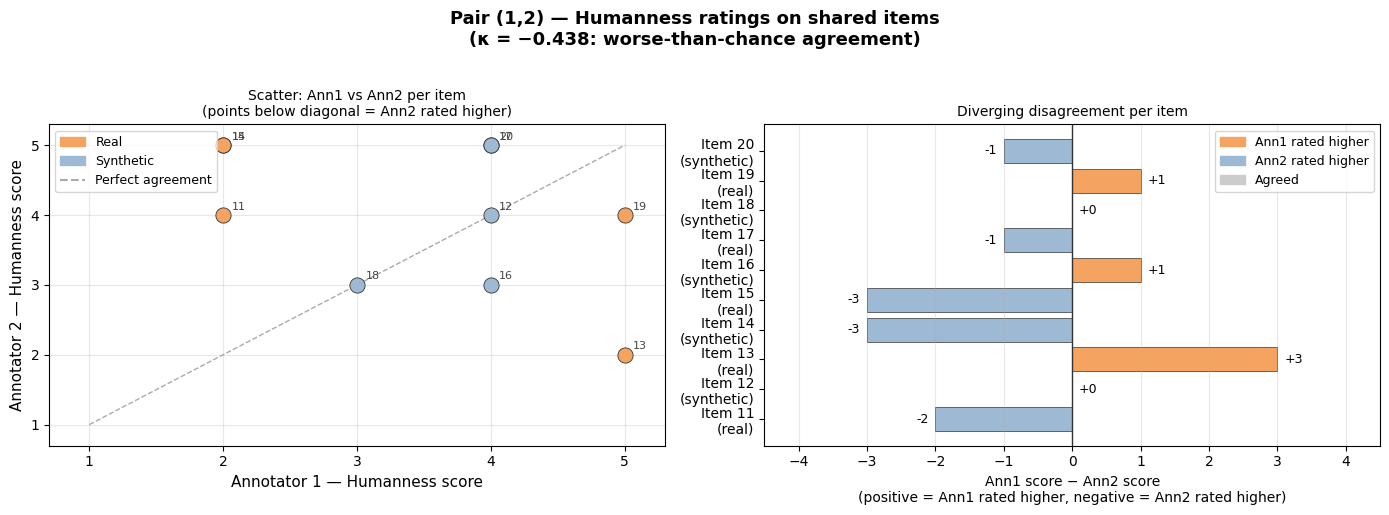


Saved: pair12_humanness_disagreement.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Step 1: get the ratings for pair (1,2) shared items ──────────────────────
ann1 = results[results['annotator_id'] == 1]
ann2 = results[results['annotator_id'] == 2]

# Find shared item_ids
shared_ids = set(ann1['item_id']) & set(ann2['item_id'])
print(f"Shared items between Ann 1 and Ann 2: {len(shared_ids)}")
print(f"Item IDs: {sorted(shared_ids)}\n")

# Merge on item_id
pair_df = ann1[ann1['item_id'].isin(shared_ids)][['item_id', 'condition', 'humanness']].merge(
    ann2[ann2['item_id'].isin(shared_ids)][['item_id', 'humanness']],
    on='item_id', suffixes=('_ann1', '_ann2')
).sort_values('item_id').reset_index(drop=True)

pair_df['disagreement'] = abs(pair_df['humanness_ann1'] - pair_df['humanness_ann2'])
pair_df['direction'] = pair_df.apply(
    lambda r: 'Ann1 higher' if r['humanness_ann1'] > r['humanness_ann2']
              else ('Ann2 higher' if r['humanness_ann2'] > r['humanness_ann1'] else 'Agree'),
    axis=1
)

print(pair_df[['item_id', 'condition', 'humanness_ann1', 'humanness_ann2', 'disagreement', 'direction']].to_string(index=False))

# ── Step 2: visualise ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pair (1,2) — Humanness ratings on shared items\n(κ = −0.438: worse-than-chance agreement)", 
             fontsize=13, fontweight='bold', y=1.02)

# ── Plot A: scatter — Ann1 vs Ann2 per item ───────────────────────────────────
ax = axes[0]
colors = {'real': '#F4A460', 'synthetic': '#9EB9D4'}

for _, row in pair_df.iterrows():
    ax.scatter(row['humanness_ann1'], row['humanness_ann2'],
               color=colors[row['condition']], s=120, zorder=3,
               edgecolors='#333333', linewidths=0.6)
    # Label item_id next to each point
    ax.annotate(str(int(row['item_id'])),
                (row['humanness_ann1'], row['humanness_ann2']),
                textcoords="offset points", xytext=(6, 4), fontsize=8, color='#444444')

# Perfect agreement diagonal
ax.plot([1, 5], [1, 5], color='#aaaaaa', linestyle='--', linewidth=1, label='Perfect agreement')

ax.set_xlim(0.7, 5.3)
ax.set_ylim(0.7, 5.3)
ax.set_xlabel("Annotator 1 — Humanness score", fontsize=11)
ax.set_ylabel("Annotator 2 — Humanness score", fontsize=11)
ax.set_title("Scatter: Ann1 vs Ann2 per item\n(points below diagonal = Ann2 rated higher)", fontsize=10)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5])
ax.grid(True, alpha=0.3)

patch_real = mpatches.Patch(color='#F4A460', label='Real')
patch_syn  = mpatches.Patch(color='#9EB9D4', label='Synthetic')
ax.legend(handles=[patch_real, patch_syn, 
                   plt.Line2D([0],[0], color='#aaaaaa', linestyle='--', label='Perfect agreement')],
          fontsize=9)

# ── Plot B: diverging bar — disagreement per item ────────────────────────────
ax2 = axes[1]
item_labels = [f"Item {int(r['item_id'])}\n({r['condition']})" for _, r in pair_df.iterrows()]
diffs = pair_df['humanness_ann1'] - pair_df['humanness_ann2']  # positive = Ann1 higher
bar_colors = ['#F4A460' if d > 0 else '#9EB9D4' if d < 0 else '#cccccc' for d in diffs]

bars = ax2.barh(item_labels, diffs, color=bar_colors, edgecolor='#333333', linewidth=0.5)
ax2.axvline(0, color='#333333', linewidth=1)
ax2.set_xlabel("Ann1 score − Ann2 score\n(positive = Ann1 rated higher, negative = Ann2 rated higher)", fontsize=10)
ax2.set_title("Diverging disagreement per item", fontsize=10)
ax2.set_xlim(-4.5, 4.5)
ax2.set_xticks(range(-4, 5))
ax2.grid(axis='x', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, diffs):
    ax2.text(val + (0.1 if val >= 0 else -0.1), bar.get_y() + bar.get_height()/2,
             f'{val:+.0f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

patch_ann1 = mpatches.Patch(color='#F4A460', label='Ann1 rated higher')
patch_ann2 = mpatches.Patch(color='#9EB9D4', label='Ann2 rated higher')
patch_agr  = mpatches.Patch(color='#cccccc', label='Agreed')
ax2.legend(handles=[patch_ann1, patch_ann2, patch_agr], fontsize=9)

plt.tight_layout()
#plt.savefig("pair12_humanness_disagreement.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: pair12_humanness_disagreement.png")



In [9]:
# ── Step 3: show actual comments for pair (1,2) humanness disagreements ───────

text_col = 'comment'

# Build comment lookup from results
comment_lookup = results.drop_duplicates('item_id')[['item_id', text_col, 'condition']]

# Merge text into pair_df
pair_df_text = pair_df.merge(comment_lookup[['item_id', text_col]], on='item_id', how='left')
pair_df_text = pair_df_text.sort_values('disagreement', ascending=False).reset_index(drop=True)

print("=" * 80)
print("PAIR (1,2) — HUMANNESS: comments sorted by disagreement (largest first)")
print("=" * 80)

for _, row in pair_df_text.iterrows():
    diff_str = f"Ann1={int(row['humanness_ann1'])}  Ann2={int(row['humanness_ann2'])}  Δ={int(row['disagreement'])}"
    print(f"\nItem {int(row['item_id'])} | {row['condition'].upper()} | {diff_str} | {row['direction']}")
    print(f"  \"{row[text_col]}\"")
    print("-" * 80)

PAIR (1,2) — HUMANNESS: comments sorted by disagreement (largest first)

Item 13 | REAL | Ann1=5  Ann2=2  Δ=3 | Ann1 higher
  "hoeveel KWh hebben de zonnepanelen op de wezenland flats opgeleverd?"
--------------------------------------------------------------------------------

Item 14 | SYNTHETIC | Ann1=2  Ann2=5  Δ=3 | Ann2 higher
  "Wauw wat goeds onderzoek An"
--------------------------------------------------------------------------------

Item 15 | REAL | Ann1=2  Ann2=5  Δ=3 | Ann2 higher
  "Ook ik heb een groot vocht probleem al zolang ik in de Halvemaanstraat woon. Heel vaak doorgegeven aan <ORG> komen kijken maar krijg niks vocht vangers hebben ze niet. Dus koop ik zelf vocht vangers om moedeloos van te worden. Maar wel is de huur weer verhoogd."
--------------------------------------------------------------------------------

Item 11 | REAL | Ann1=2  Ann2=4  Δ=2 | Ann2 higher
  "Zo zijn ze ook bij mijn moeder geweest... althans alleen het bloemetje dan. Nadat ze na het overli

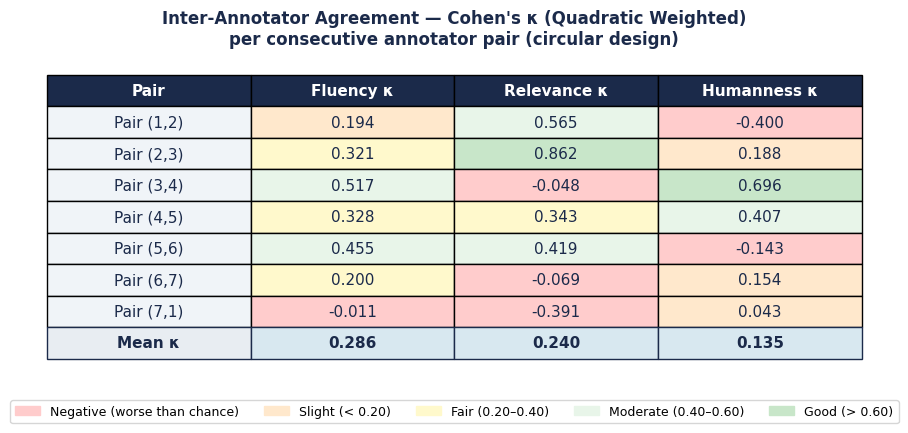

Saved: kappa_table.png


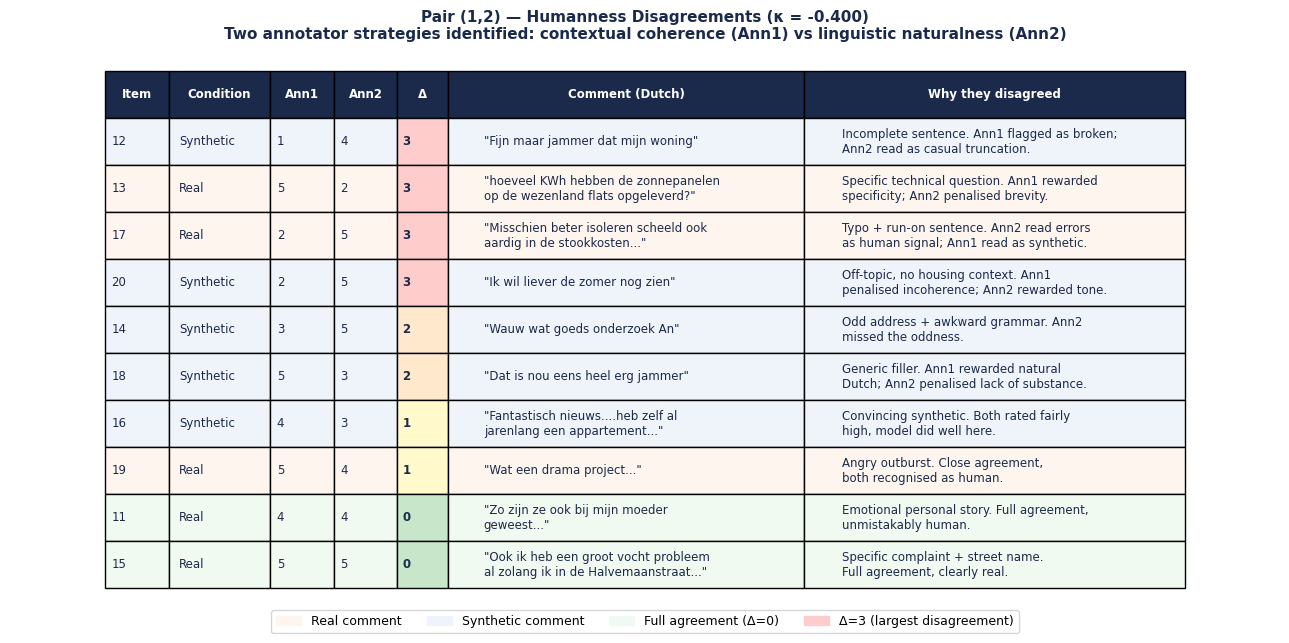

Saved: pair12_qualitative_table.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Read kappa values dynamically from kappa_df ───────────────────────────────
pair_order   = [f"({a},{b})" for a, b in overlap_pairs]
kappa_pivot  = (kappa_df.pivot(index='pair', columns='metric', values='kappa')
                .reindex(pair_order))

pairs     = [f"Pair {p}" for p in pair_order] + ['Mean κ']
fluency   = list(kappa_pivot['fluency'])   + [kappa_df[kappa_df['metric'] == 'fluency']['kappa'].mean()]
relevance = list(kappa_pivot['relevance']) + [kappa_df[kappa_df['metric'] == 'relevance']['kappa'].mean()]
humanness = list(kappa_pivot['humanness']) + [kappa_df[kappa_df['metric'] == 'humanness']['kappa'].mean()]

def kappa_color(v):
    if v < 0:     return '#FFCCCC'   # red   — worse than chance
    elif v < 0.2: return '#FFE8CC'   # amber — slight
    elif v < 0.4: return '#FFF9CC'   # yellow — fair
    elif v < 0.6: return '#E8F5E9'   # light green — moderate
    else:         return '#C8E6C9'   # green — good

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — κ table
# ═══════════════════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.axis('off')

col_labels = ['Pair', 'Fluency κ', 'Relevance κ', 'Humanness κ']
table_data = [[p, f"{f:.3f}", f"{r:.3f}", f"{h:.3f}"]
              for p, f, r, h in zip(pairs, fluency, relevance, humanness)]

table = ax1.table(cellText=table_data, colLabels=col_labels,
                  loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.1)

# Header row
for j in range(4):
    table[0, j].set_facecolor('#1B2A4A')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Data rows — color by kappa value
for i, (f, r, h) in enumerate(zip(fluency, relevance, humanness), start=1):
    is_mean = (i == len(pairs))
    table[i, 0].set_facecolor('#F0F4F8' if not is_mean else '#E8EDF2')
    table[i, 0].set_text_props(fontweight='bold' if is_mean else 'normal',
                                color='#1B2A4A')
    for j, val in enumerate([f, r, h], start=1):
        table[i, j].set_facecolor('#D8E8F0' if is_mean else kappa_color(val))
        table[i, j].set_text_props(fontweight='bold' if is_mean else 'normal',
                                    color='#1B2A4A')

# Divider before mean row
for j in range(4):
    table[len(pairs), j].set_edgecolor('#1B2A4A')

ax1.set_title("Inter-Annotator Agreement — Cohen's κ (Quadratic Weighted)\nper consecutive annotator pair (circular design)",
              fontsize=12, fontweight='bold', color='#1B2A4A', pad=12)

legend_items = [
    mpatches.Patch(color='#FFCCCC', label='Negative (worse than chance)'),
    mpatches.Patch(color='#FFE8CC', label='Slight (< 0.20)'),
    mpatches.Patch(color='#FFF9CC', label='Fair (0.20–0.40)'),
    mpatches.Patch(color='#E8F5E9', label='Moderate (0.40–0.60)'),
    mpatches.Patch(color='#C8E6C9', label='Good (> 0.60)'),
]
ax1.legend(handles=legend_items, loc='lower center',
           bbox_to_anchor=(0.5, -0.18), ncol=5, fontsize=9,
           frameon=True, edgecolor='#cccccc')

plt.tight_layout()
#plt.savefig('kappa_table.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: kappa_table.png")


# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Pair (1,2) qualitative comment analysis
# ═══════════════════════════════════════════════════════════════════════════════
pair12_k = kappa_df[(kappa_df['pair'] == '(1,2)') & (kappa_df['metric'] == 'humanness')]['kappa'].values[0]

fig2, ax2 = plt.subplots(figsize=(13, 6.5))
ax2.axis('off')

col_labels2 = ['Item', 'Condition', 'Ann1', 'Ann2', 'Δ', 'Comment (Dutch)', 'Why they disagreed']
table_data2 = [
    ['12', 'Synthetic', '1', '4', '3', '"Fijn maar jammer dat mijn woning"',        'Incomplete sentence. Ann1 flagged as broken;\nAnn2 read as casual truncation.'],
    ['13', 'Real',      '5', '2', '3', '"hoeveel KWh hebben de zonnepanelen\nop de wezenland flats opgeleverd?"', 'Specific technical question. Ann1 rewarded\nspecificity; Ann2 penalised brevity.'],
    ['17', 'Real',      '2', '5', '3', '"Misschien beter isoleren scheeld ook\naardig in de stookkosten..."',      'Typo + run-on sentence. Ann2 read errors\nas human signal; Ann1 read as synthetic.'],
    ['20', 'Synthetic', '2', '5', '3', '"Ik wil liever de zomer nog zien"',          'Off-topic, no housing context. Ann1\npenalised incoherence; Ann2 rewarded tone.'],
    ['14', 'Synthetic', '3', '5', '2', '"Wauw wat goeds onderzoek An"',              'Odd address + awkward grammar. Ann2\nmissed the oddness.'],
    ['18', 'Synthetic', '5', '3', '2', '"Dat is nou eens heel erg jammer"',          'Generic filler. Ann1 rewarded natural\nDutch; Ann2 penalised lack of substance.'],
    ['16', 'Synthetic', '4', '3', '1', '"Fantastisch nieuws....heb zelf al\njarenlang een appartement..."',        'Convincing synthetic. Both rated fairly\nhigh, model did well here.'],
    ['19', 'Real',      '5', '4', '1', '"Wat een drama project..."',                 'Angry outburst. Close agreement,\nboth recognised as human.'],
    ['11', 'Real',      '4', '4', '0', '"Zo zijn ze ook bij mijn moeder\ngeweest..."',                             'Emotional personal story. Full agreement,\nunmistakably human.'],
    ['15', 'Real',      '5', '5', '0', '"Ook ik heb een groot vocht probleem\nal zolang ik in de Halvemaanstraat..."', 'Specific complaint + street name.\nFull agreement, clearly real.'],
]

table2 = ax2.table(cellText=table_data2, colLabels=col_labels2,
                   loc='center', cellLoc='left')
table2.auto_set_font_size(False)
table2.set_fontsize(8.5)
table2.scale(1.0, 2.55)

col_widths = [0.05, 0.08, 0.05, 0.05, 0.04, 0.28, 0.30]
for j, w in enumerate(col_widths):
    for i in range(len(table_data2) + 1):
        table2[i, j].set_width(w)

for j in range(7):
    table2[0, j].set_facecolor('#1B2A4A')
    table2[0, j].set_text_props(color='white', fontweight='bold')

syn_fill   = '#EEF4FA'
real_fill  = '#FEF6EE'
agree_fill = '#F0FAF0'

for i, row in enumerate(table_data2, start=1):
    cond     = row[1]
    delta    = int(row[4])
    is_agree = delta == 0
    bg = agree_fill if is_agree else (syn_fill if cond == 'Synthetic' else real_fill)
    for j in range(7):
        table2[i, j].set_facecolor(bg)
        table2[i, j].set_text_props(color='#1B2A4A')
    delta_color = '#FFCCCC' if delta == 3 else '#FFE8CC' if delta == 2 else '#FFF9CC' if delta == 1 else '#C8E6C9'
    table2[i, 4].set_facecolor(delta_color)
    table2[i, 4].set_text_props(fontweight='bold', color='#1B2A4A')

ax2.set_title(
    f"Pair (1,2) — Humanness Disagreements (κ = {pair12_k:.3f})\n"
    "Two annotator strategies identified: contextual coherence (Ann1) vs linguistic naturalness (Ann2)",
    fontsize=11, fontweight='bold', color='#1B2A4A', pad=10
)

legend2 = [
    mpatches.Patch(color=real_fill,  label='Real comment'),
    mpatches.Patch(color=syn_fill,   label='Synthetic comment'),
    mpatches.Patch(color=agree_fill, label='Full agreement (Δ=0)'),
    mpatches.Patch(color='#FFCCCC',  label='Δ=3 (largest disagreement)'),
]
ax2.legend(handles=legend2, loc='lower center',
           bbox_to_anchor=(0.5, -0.06), ncol=4, fontsize=9,
           frameon=True, edgecolor='#cccccc')

plt.tight_layout()
#plt.savefig('pair12_qualitative_table.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: pair12_qualitative_table.png")

## Step 4A — cONSIDER ANNOTTAOR 1 RATING Per Item

Circular design: all 70 items (item_ids 11–80) are seen by exactly 2 annotators.  
For each item the **first** annotator's rating in the overlap pair is used (e.g. pair (1,2) → Ann 1, pair (7,1) → Ann 7).

In [11]:
# For shared items, keep only the "first" annotator's rating per overlap pair:
# (1,2) → Ann 1, (2,3) → Ann 2, ..., (6,7) → Ann 6, (7,1) → Ann 7
item_to_first_ann = {}
for ann_a, ann_b in overlap_pairs:
    items_a = set(results[results['annotator_id'] == ann_a]['item_id'])
    items_b = set(results[results['annotator_id'] == ann_b]['item_id'])
    for iid in items_a & items_b:
        item_to_first_ann[iid] = ann_a

results['first_ann'] = results['item_id'].map(item_to_first_ann)

item_scores = (results[results['annotator_id'] == results['first_ann']]
               .groupby(['item_id', 'pair_id', 'condition'])[metrics]
               .mean()
               .reset_index())

print("=== MEAN SCORES PER CONDITION ===")
print(item_scores.groupby('condition')[metrics].mean().round(3).to_string())

=== MEAN SCORES PER CONDITION ===
           fluency  relevance  humanness
condition                               
real         4.086      3.714      4.057
synthetic    3.686      3.029      3.657


## Step 5A — Mann-Whitney U Test (Real vs Synthetic) - CONSIDER ANNOTATOR 1 RATING

In [12]:
print("=== REAL vs SYNTHETIC (Mann-Whitney U) ===")

real = item_scores[item_scores['condition'] == 'real']
syn  = item_scores[item_scores['condition'] == 'synthetic']

stat_records = []

for metric in metrics:
    stat, p = mannwhitneyu(
        real[metric].values,
        syn[metric].values,
        alternative='two-sided'
    )
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    stat_records.append({
        'metric':    metric,
        'real_median': round(real[metric].median(), 3),
        'syn_median':  round(syn[metric].median(), 3),
        'U':         stat,
        'p':         round(p, 4),
        'sig':       sig
    })
    print(f"  {metric:>10}: real={real[metric].median():.2f}, "
          f"synthetic={syn[metric].median():.2f}, "
          f"U={stat:.0f}, p={p:.3f} {sig}")

=== REAL vs SYNTHETIC (Mann-Whitney U) ===
     fluency: real=4.00, synthetic=4.00, U=711, p=0.228 ns
   relevance: real=4.00, synthetic=3.00, U=816, p=0.014 *
   humanness: real=4.00, synthetic=4.00, U=762, p=0.067 ns


In [18]:
from statsmodels.stats.multitest import multipletests

pvals = [r['p'] for r in stat_records]  # [0.041, 0.012, 0.031]

reject_bh, pvals_bh, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
reject_bon, pvals_bon, _, _ = multipletests(pvals, alpha=0.05, method='bonferroni')

for i, metric in enumerate(metrics):
    print(f"{metric}: p={pvals[i]:.3f} | BH-corrected={pvals_bh[i]:.3f} ({'' if reject_bh[i] else 'not '}sig) | Bonf-corrected={pvals_bon[i]:.3f} ({'' if reject_bon[i] else 'not '}sig)")

fluency: p=0.228 | BH-corrected=0.228 (not sig) | Bonf-corrected=0.683 (not sig)
relevance: p=0.014 | BH-corrected=0.042 (sig) | Bonf-corrected=0.042 (sig)
humanness: p=0.067 | BH-corrected=0.101 (not sig) | Bonf-corrected=0.202 (not sig)


## Step 4B — cONSIDER ANNOTTAOR 2 RATING Per Item

Circular design: all 70 items (item_ids 11–80) are seen by exactly 2 annotators.  
For each item the **second** annotator's rating in the overlap pair is used (e.g. pair (1,2) → Ann 2, pair (7,1) → Ann 1).

In [19]:
# For shared items, keep only the "first" annotator's rating per overlap pair:
# (1,2) → Ann 2, (2,3) → Ann 3, ..., (6,7) → Ann 7, (7,1) → Ann 1
item_to_first_ann = {}
for ann_a, ann_b in overlap_pairs:
    items_a = set(results[results['annotator_id'] == ann_a]['item_id'])
    items_b = set(results[results['annotator_id'] == ann_b]['item_id'])
    for iid in items_a & items_b:
        item_to_first_ann[iid] = ann_b

results['first_ann'] = results['item_id'].map(item_to_first_ann)

item_scores = (results[results['annotator_id'] == results['first_ann']]
               .groupby(['item_id', 'pair_id', 'condition'])[metrics]
               .mean()
               .reset_index())

print("=== MEAN SCORES PER CONDITION ===")
print(item_scores.groupby('condition')[metrics].mean().round(3).to_string())

=== MEAN SCORES PER CONDITION ===
           fluency  relevance  humanness
condition                               
real         4.314      3.686      3.914
synthetic    3.543      3.229      3.971


## Step 5B — Mann-Whitney U Test (Real vs Synthetic) - CONSIDER ANNOTATOR 2 RATING

In [20]:
print("=== REAL vs SYNTHETIC (Mann-Whitney U) ===")

real = item_scores[item_scores['condition'] == 'real']
syn  = item_scores[item_scores['condition'] == 'synthetic']

stat_records = []

for metric in metrics:
    stat, p = mannwhitneyu(
        real[metric].values,
        syn[metric].values,
        alternative='two-sided'
    )
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    stat_records.append({
        'metric':    metric,
        'real_median': round(real[metric].median(), 3),
        'syn_median':  round(syn[metric].median(), 3),
        'U':         stat,
        'p':         round(p, 4),
        'sig':       sig
    })
    print(f"  {metric:>10}: real={real[metric].median():.2f}, "
          f"synthetic={syn[metric].median():.2f}, "
          f"U={stat:.0f}, p={p:.3f} {sig}")

=== REAL vs SYNTHETIC (Mann-Whitney U) ===
     fluency: real=5.00, synthetic=4.00, U=862, p=0.002 **
   relevance: real=4.00, synthetic=3.00, U=736, p=0.139 ns
   humanness: real=4.00, synthetic=4.00, U=606, p=0.946 ns


In [22]:
from statsmodels.stats.multitest import multipletests

pvals = [r['p'] for r in stat_records]  # [0.041, 0.012, 0.031]

reject_bh, pvals_bh, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
reject_bon, pvals_bon, _, _ = multipletests(pvals, alpha=0.05, method='bonferroni')

for i, metric in enumerate(metrics):
    print(f"{metric}: p={pvals[i]:.3f} | BH-corrected={pvals_bh[i]:.3f} ({'' if reject_bh[i] else 'not '}sig) | Bonf-corrected={pvals_bon[i]:.3f} ({'' if reject_bon[i] else 'not '}sig)")

fluency: p=0.002 | BH-corrected=0.006 (sig) | Bonf-corrected=0.006 (sig)
relevance: p=0.139 | BH-corrected=0.208 (not sig) | Bonf-corrected=0.416 (not sig)
humanness: p=0.946 | BH-corrected=0.946 (not sig) | Bonf-corrected=1.000 (not sig)


In [23]:
# ── ROBUSTNESS CHECK: overlap items only (2-annotator confirmed) ──────────────
# Circular design: item_ids 11–80 are each seen by 2 annotators (70 items, 35 real + 35 synthetic).
# Item_ids 1–10 are dropped (no annotator covers them after the redesign).
# ──────────────────────────────────────────────────────────────────────────────

from scipy.stats import mannwhitneyu

print("=== ROBUSTNESS CHECK: overlap items only ===")
print("(Items rated by exactly 2 annotators — 70 items, 35 real + 35 synthetic)\n")

# Step 1: find which item_ids were rated by exactly 2 annotators
item_counts      = results.groupby('item_id')['annotator_id'].nunique()
overlap_item_ids = item_counts[item_counts == 2].index

print(f"Overlap items found: {len(overlap_item_ids)}")
print(f"Expected: 70  {'✓' if len(overlap_item_ids) == 70 else '← check this'}\n")

# Step 2: filter and average
overlap_df  = results[results['item_id'].isin(overlap_item_ids)]
overlap_avg = overlap_df.groupby(['item_id', 'condition'])[metrics].mean().reset_index()

real_n = (overlap_avg['condition'] == 'real').sum()
syn_n  = (overlap_avg['condition'] == 'synthetic').sum()
print(f"Items per condition — Real: {real_n}, Synthetic: {syn_n}")
print(f"Expected: 35 each  {'✓' if real_n == 35 and syn_n == 35 else '← check this'}\n")

# Step 3: re-run Mann-Whitney on overlap items only
print(f"{'Metric':<12} {'U (overlap)':>12} {'p (overlap)':>12} {'sig':>5} │ {'U (full)':>10} {'p (full)':>10} {'Consistent?':>12}")
print("─" * 80)

real_ov = overlap_avg[overlap_avg['condition'] == 'real']
syn_ov  = overlap_avg[overlap_avg['condition'] == 'synthetic']

for metric in metrics:
    U_ov, p_ov = mannwhitneyu(real_ov[metric], syn_ov[metric], alternative='two-sided')
    sig_ov   = '*' if p_ov < 0.05 else 'ns'
    orig     = next(r for r in stat_records if r['metric'] == metric)
    consistent = '✓ same' if sig_ov == orig['sig'] else '✗ differs'
    print(f"  {metric:<10} {U_ov:>12.0f} {p_ov:>12.3f} {sig_ov:>5} │ {orig['U']:>10.0f} {orig['p']:>10.3f} {consistent:>12}")

print("\nInterpretation:")
print("  ✓ same   → finding holds in confirmed-rating items; main result is robust")
print("  ✗ differs → main result may be partly driven by single-annotator noise")

=== ROBUSTNESS CHECK: overlap items only ===
(Items rated by exactly 2 annotators — 70 items, 35 real + 35 synthetic)

Overlap items found: 70
Expected: 70  ✓

Items per condition — Real: 35, Synthetic: 35
Expected: 35 each  ✓

Metric        U (overlap)  p (overlap)   sig │   U (full)   p (full)  Consistent?
────────────────────────────────────────────────────────────────────────────────
  fluency             832        0.009     * │        862      0.002    ✗ differs
  relevance           822        0.013     * │        736      0.139    ✗ differs
  humanness           690        0.357    ns │        606      0.946       ✓ same

Interpretation:
  ✓ same   → finding holds in confirmed-rating items; main result is robust
  ✗ differs → main result may be partly driven by single-annotator noise


## Step 6 — Boxplots

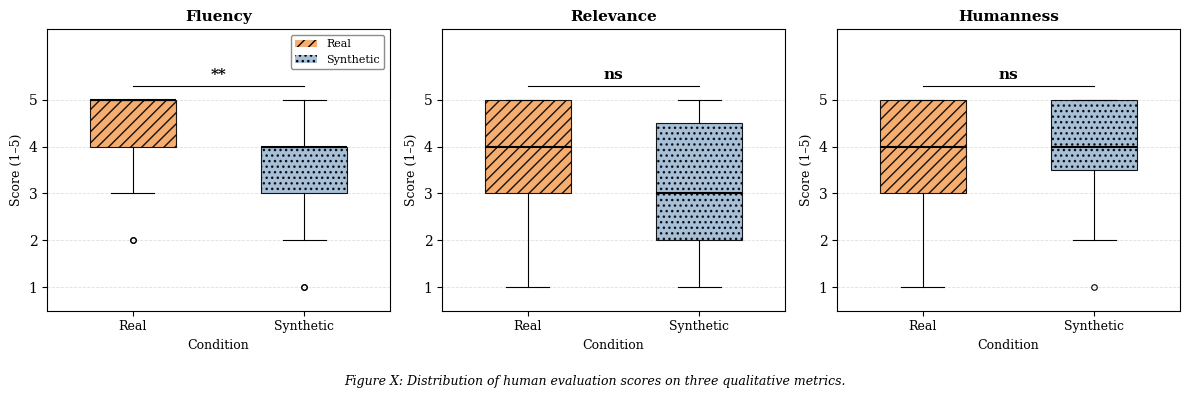

In [24]:
plt.rcParams.update({
    'font.family':    'serif',
    'font.size':      10,
    'axes.linewidth': 0.8
})

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

colors     = {'real': '#F4A460', 'synthetic': '#9EB9D4'}
hatches    = {'real': '///',     'synthetic': '...'}
conditions = ['real', 'synthetic']
labels     = ['Real', 'Synthetic']

for ax, metric in zip(axes, metrics):

    data_to_plot = [
        item_scores[item_scores['condition'] == cond][metric].dropna().values
        for cond in conditions
    ]

    bp = ax.boxplot(
        data_to_plot,
        positions=[1, 2],
        patch_artist=True,
        widths=0.5,
        showfliers=True,
        flierprops=dict(marker='o', markersize=4,
                        markerfacecolor='none',
                        markeredgewidth=0.8),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        boxprops=dict(linewidth=0.8)
    )

    for patch, cond in zip(bp['boxes'], conditions):
        patch.set_facecolor(colors[cond])
        patch.set_hatch(hatches[cond])
        patch.set_alpha(0.9)

    stat_row = next(s for s in stat_records if s['metric'] == metric)
    y_bar = max(
        item_scores[item_scores['condition'] == 'real'][metric].max(),
        item_scores[item_scores['condition'] == 'synthetic'][metric].max()
    ) + 0.3
    ax.plot([1, 2], [y_bar, y_bar], color='black', linewidth=0.8)
    ax.text(1.5, y_bar + 0.07, stat_row['sig'],
            ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_title(metric.capitalize(), fontsize=11, fontweight='bold', pad=6)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_xlabel('Condition', fontsize=9, labelpad=4)
    ax.set_ylabel('Score (1–5)', fontsize=9)
    ax.set_ylim(0.5, 6.5)          # extended range so whiskers at 1 and 5 are fully visible
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.6)
    ax.set_axisbelow(True)

    if ax == axes[0]:
        legend_handles = [
            mpatches.Patch(
                facecolor=colors[cond],
                hatch=hatches[cond],
                alpha=0.9,
                label=label,
                linewidth=0.8
            )
            for cond, label in zip(conditions, labels)
        ]
        ax.legend(
            handles=legend_handles,
            loc='upper right',
            fontsize=8,
            frameon=True,
            framealpha=0.9,
            edgecolor='gray'
        )

plt.suptitle(
    'Figure X: Distribution of human evaluation scores on three qualitative metrics.',
    fontsize=9,
    y=-0.02,
    style='italic'
)

plt.tight_layout()
plt.savefig(f"{results_base}\\human_eval_boxplots.png", dpi=300, bbox_inches='tight')
plt.show()

## Step 7 — Save All Results

In [25]:
item_scores.to_csv(f"{results_base}\\item_scores_averaged.csv", index=False)
kappa_df.to_csv(f"{results_base}\\kappa_results.csv", index=False)
pd.DataFrame(stat_records).to_csv(f"{results_base}\\mannwhitney_results.csv", index=False)

print("Saved:")
print("  item_scores_averaged.csv  — averaged scores per item")
print("  kappa_results.csv         — Cohen's κ per overlap pair per metric")
print("  mannwhitney_results.csv   — Mann-Whitney U results")
print("  human_eval_boxplots.png   — figure for paper")

Saved:
  item_scores_averaged.csv  — averaged scores per item
  kappa_results.csv         — Cohen's κ per overlap pair per metric
  mannwhitney_results.csv   — Mann-Whitney U results
  human_eval_boxplots.png   — figure for paper


## Step 8 — Score Distributions (KDE, all 140 raw annotations)

Kernel density estimate of the raw scores for each metric, using every annotation as given (no per-item averaging or first/second-annotator collapsing) — 140 rows = 7 annotators × 20 items each.

In [27]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


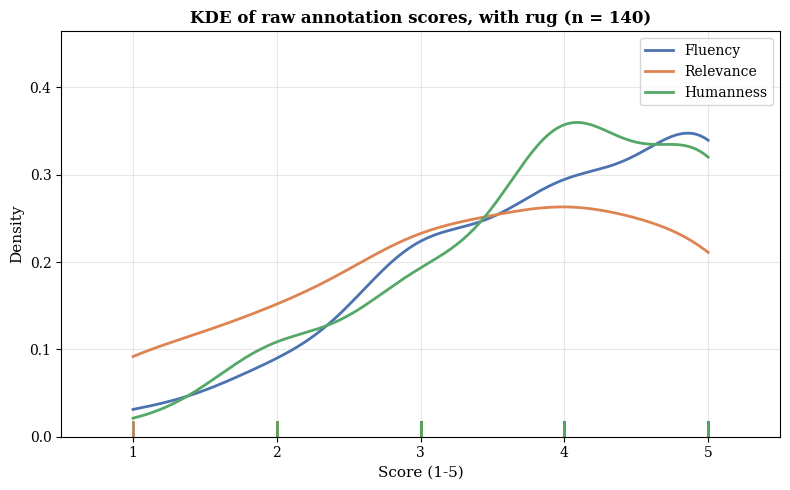

       fluency  relevance  humanness
count  140.000    140.000    140.000
mean     3.907      3.414      3.900
std      1.086      1.275      1.034
min      1.000      1.000      1.000
25%      3.000      3.000      3.000
50%      4.000      4.000      4.000
75%      5.000      4.000      5.000
max      5.000      5.000      5.000


In [28]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))

colors = {'fluency': '#4C72B0', 'relevance': '#DD8452', 'humanness': '#55A868'}

for metric in metrics:
    sns.kdeplot(
        results[metric],
        label=metric.capitalize(),
        color=colors[metric],
        linewidth=2,
        bw_adjust=1.2,
        clip=(1, 5),
        ax=ax
    )
    sns.rugplot(
        results[metric],
        color=colors[metric],
        height=0.04,
        alpha=0.5,
        ax=ax
    )

ax.set_xlim(0.5, 5.5)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlabel("Score (1-5)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(f"KDE of raw annotation scores, with rug (n = {len(results)})", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{results_base}\\raw_scores_kde.png", dpi=150, bbox_inches='tight')
plt.show()

print(results[metrics].describe().round(3))

## Step 8b — Score Distributions (Grouped Bar Chart)

Likert scores are discrete (1–5), so a count/bar chart avoids the smoothing artifacts of KDE and shows the exact tie structure of the raw scores.

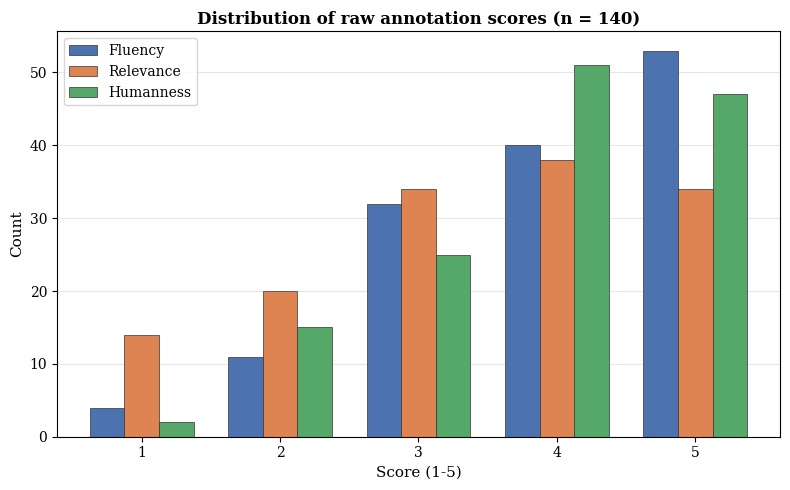

   fluency  relevance  humanness
1        4         14          2
2       11         20         15
3       32         34         25
4       40         38         51
5       53         34         47


In [29]:
scale = [1, 2, 3, 4, 5]
counts = pd.DataFrame({
    metric: results[metric].value_counts().reindex(scale, fill_value=0)
    for metric in metrics
})

x = np.arange(len(scale))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

for i, metric in enumerate(metrics):
    ax.bar(
        x + (i - 1) * width,
        counts[metric].values,
        width=width,
        label=metric.capitalize(),
        color=colors[metric],
        edgecolor='#333333',
        linewidth=0.5
    )

ax.set_xticks(x)
ax.set_xticklabels(scale)
ax.set_xlabel("Score (1-5)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(f"Distribution of raw annotation scores (n = {len(results)})", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{results_base}\\raw_scores_bar.png", dpi=150, bbox_inches='tight')
plt.show()

print(counts)

## Step 9 — Score Distributions by Condition (Real vs Synthetic, KDE)

Same raw 140 annotations, now split by condition — one panel per metric, real vs synthetic overlaid.

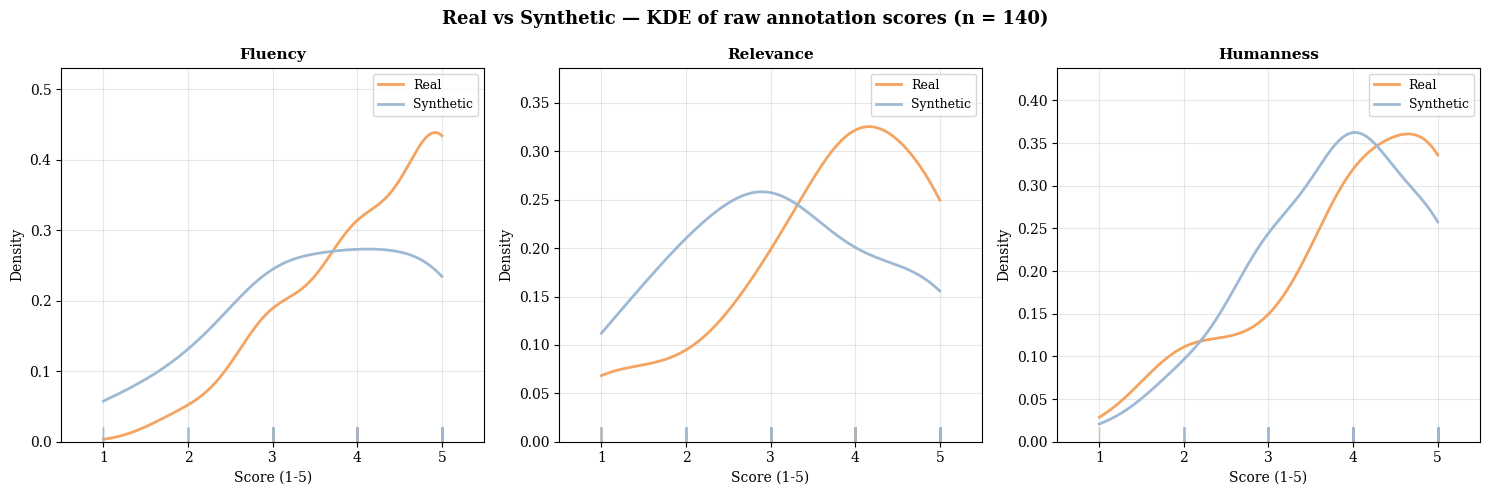

condition          real  synthetic
fluency   count  70.000     70.000
          mean    4.200      3.614
          std     0.894      1.183
          min     2.000      1.000
          25%     4.000      3.000
          50%     4.000      4.000
          75%     5.000      5.000
          max     5.000      5.000
relevance count  70.000     70.000
          mean    3.700      3.129
          std     1.208      1.284
          min     1.000      1.000
          25%     3.000      2.000
          50%     4.000      3.000
          75%     5.000      4.000
          max     5.000      5.000
humanness count  70.000     70.000
          mean    3.986      3.814
          std     1.083      0.982
          min     1.000      1.000
          25%     3.250      3.000
          50%     4.000      4.000
          75%     5.000      5.000
          max     5.000      5.000


In [30]:
cond_colors = {'real': '#F4A460', 'synthetic': '#9EB9D4'}
conditions = ['real', 'synthetic']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, metric in zip(axes, metrics):
    for cond in conditions:
        data = results[results['condition'] == cond][metric]
        sns.kdeplot(data, label=cond.capitalize(), color=cond_colors[cond],
                    linewidth=2, bw_adjust=1.2, clip=(1, 5), ax=ax)
        sns.rugplot(data, color=cond_colors[cond], height=0.04, alpha=0.5, ax=ax)

    ax.set_xlim(0.5, 5.5)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xlabel("Score (1-5)", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_title(metric.capitalize(), fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Real vs Synthetic — KDE of raw annotation scores (n = {len(results)})",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{results_base}\\raw_scores_kde_by_condition.png", dpi=150, bbox_inches='tight')
plt.show()

print(results.groupby('condition')[metrics].describe().round(3).T)

## Step 9b — Score Distributions by Condition (Real vs Synthetic, Bar Chart)

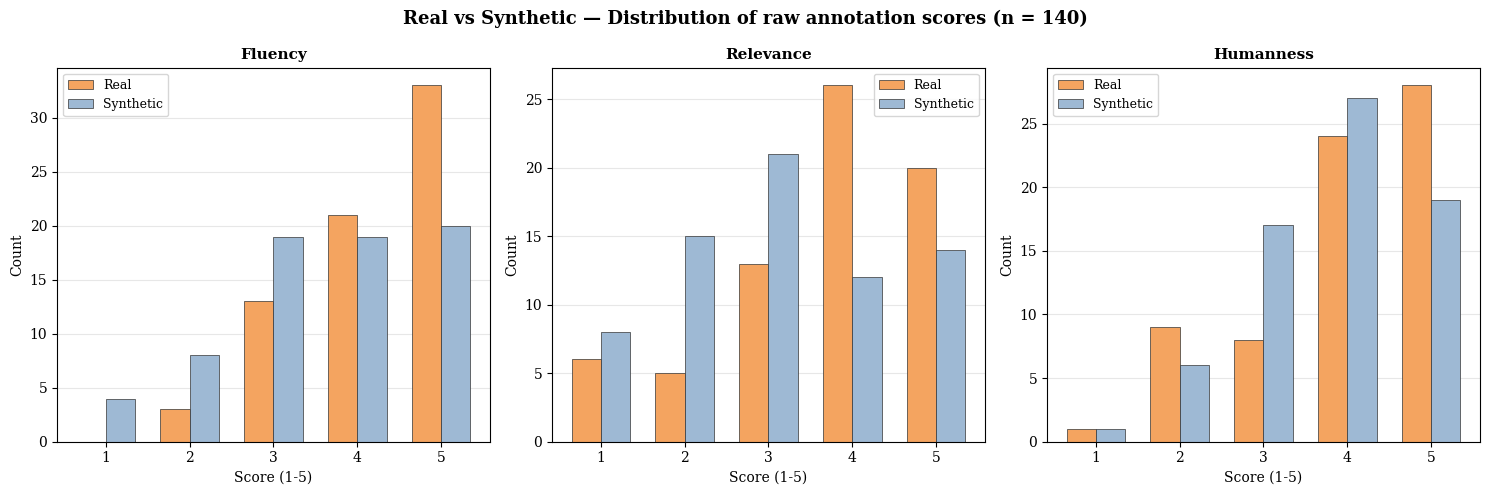

In [31]:
scale = [1, 2, 3, 4, 5]
x = np.arange(len(scale))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, metric in zip(axes, metrics):
    counts_by_cond = {
        cond: results[results['condition'] == cond][metric].value_counts().reindex(scale, fill_value=0)
        for cond in conditions
    }
    for i, cond in enumerate(conditions):
        ax.bar(
            x + (i - 0.5) * width,
            counts_by_cond[cond].values,
            width=width,
            label=cond.capitalize(),
            color=cond_colors[cond],
            edgecolor='#333333',
            linewidth=0.5
        )

    ax.set_xticks(x)
    ax.set_xticklabels(scale)
    ax.set_xlabel("Score (1-5)", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(metric.capitalize(), fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle(f"Real vs Synthetic — Distribution of raw annotation scores (n = {len(results)})",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{results_base}\\raw_scores_bar_by_condition.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Annotator A vs Annotator B, by Condition (KDE)

For each of the 70 overlap items, "Ann A" = the first annotator in the circular pair (e.g. pair (1,2) → Ann 1), "Ann B" = the second (e.g. pair (1,2) → Ann 2). This shows whether the two annotator positions rate real/synthetic items differently, for each metric.

Ann A/B long-format rows: 420 (expect 70 items x 3 metrics x 2 = 420)


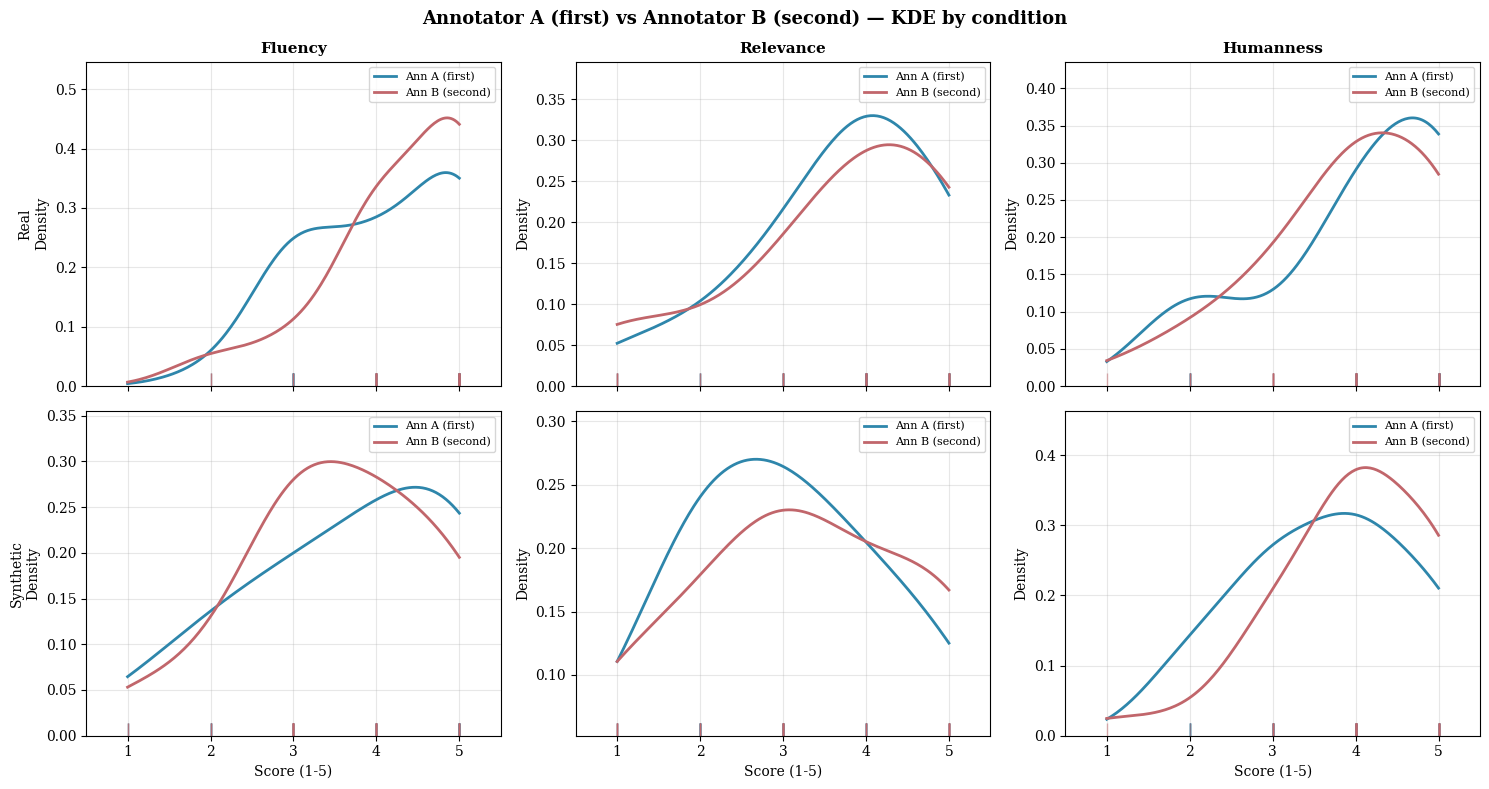

                                    count   mean    std  min  25%  50%  75%  \
condition metric    ann_label                                                 
real      fluency   Ann A (first)    35.0  4.086  0.919  2.0  3.0  4.0  5.0   
                    Ann B (second)   35.0  4.314  0.867  2.0  4.0  5.0  5.0   
          humanness Ann A (first)    35.0  4.057  1.110  2.0  4.0  4.0  5.0   
                    Ann B (second)   35.0  3.914  1.067  1.0  3.0  4.0  5.0   
          relevance Ann A (first)    35.0  3.714  1.126  1.0  3.0  4.0  4.5   
                    Ann B (second)   35.0  3.686  1.301  1.0  3.0  4.0  5.0   
synthetic fluency   Ann A (first)    35.0  3.686  1.255  1.0  3.0  4.0  5.0   
                    Ann B (second)   35.0  3.543  1.120  1.0  3.0  4.0  4.0   
          humanness Ann A (first)    35.0  3.657  0.998  2.0  3.0  4.0  4.0   
                    Ann B (second)   35.0  3.971  0.954  1.0  3.5  4.0  5.0   
          relevance Ann A (first)    35.0  3.029  1.

In [32]:
# ── Build per-item Ann A / Ann B lookup from the circular overlap pairs ───────
item_to_ann_a = {}
item_to_ann_b = {}
for ann_a, ann_b in overlap_pairs:
    items_a = set(results[results['annotator_id'] == ann_a]['item_id'])
    items_b = set(results[results['annotator_id'] == ann_b]['item_id'])
    for iid in items_a & items_b:
        item_to_ann_a[iid] = ann_a
        item_to_ann_b[iid] = ann_b

ab_records = []
for iid, ann_a in item_to_ann_a.items():
    ann_b = item_to_ann_b[iid]
    row_a = results[(results['item_id'] == iid) & (results['annotator_id'] == ann_a)].iloc[0]
    row_b = results[(results['item_id'] == iid) & (results['annotator_id'] == ann_b)].iloc[0]
    for metric in metrics:
        ab_records.append({'item_id': iid, 'condition': row_a['condition'],
                            'metric': metric, 'ann_label': 'Ann A (first)', 'score': row_a[metric]})
        ab_records.append({'item_id': iid, 'condition': row_b['condition'],
                            'metric': metric, 'ann_label': 'Ann B (second)', 'score': row_b[metric]})

ab_df = pd.DataFrame(ab_records)
print(f"Ann A/B long-format rows: {len(ab_df)} (expect 70 items x 3 metrics x 2 = 420)")

ann_colors = {'Ann A (first)': '#2E86AB', 'Ann B (second)': '#C1666B'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

for row, cond in enumerate(conditions):
    for col, metric in enumerate(metrics):
        ax = axes[row, col]
        sub = ab_df[(ab_df['condition'] == cond) & (ab_df['metric'] == metric)]
        for label in ['Ann A (first)', 'Ann B (second)']:
            data = sub[sub['ann_label'] == label]['score']
            sns.kdeplot(data, label=label, color=ann_colors[label],
                        linewidth=2, bw_adjust=1.2, clip=(1, 5), ax=ax)
            sns.rugplot(data, color=ann_colors[label], height=0.04, alpha=0.5, ax=ax)

        ax.set_xlim(0.5, 5.5)
        ax.set_xticks([1, 2, 3, 4, 5])
        if row == 1:
            ax.set_xlabel("Score (1-5)", fontsize=10)
        if col == 0:
            ax.set_ylabel(f"{cond.capitalize()}\nDensity", fontsize=10)
        if row == 0:
            ax.set_title(metric.capitalize(), fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle("Annotator A (first) vs Annotator B (second) — KDE by condition",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{results_base}\\raw_scores_kde_by_annotator_and_condition.png", dpi=150, bbox_inches='tight')
plt.show()

print(ab_df.groupby(['condition', 'metric', 'ann_label'])['score'].describe().round(3))

## Step 11 — Correlation Between Metrics

Pairwise correlation (Pearson + Spearman) between fluency, relevance, and humanness on all 140 raw annotations. Spearman is the primary measure since these are ordinal 1–5 Likert scores.

=== CORRELATION BETWEEN METRICS (raw annotations, n=140) ===

     fluency vs relevance : Pearson r=0.262 (p=0.0018)  |  Spearman ρ=0.274 (p=0.0010)
     fluency vs humanness : Pearson r=0.357 (p=0.0000)  |  Spearman ρ=0.352 (p=0.0000)
   relevance vs humanness : Pearson r=0.381 (p=0.0000)  |  Spearman ρ=0.390 (p=0.0000)


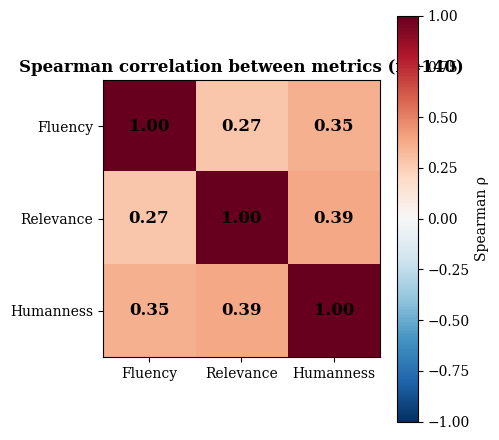

,pair,pearson_r,pearson_p,spearman_rho,spearman_p
0,fluency vs relevance,0.262,0.0018,0.274,0.001
1,fluency vs humanness,0.357,0.0000,0.352,0.000
2,relevance vs humanness,0.381,0.0000,0.390,0.000


In [33]:
from scipy.stats import pearsonr, spearmanr

print("=== CORRELATION BETWEEN METRICS (raw annotations, n=140) ===\n")

corr_records = []
metric_pairs = [('fluency', 'relevance'), ('fluency', 'humanness'), ('relevance', 'humanness')]

for m1, m2 in metric_pairs:
    r_pearson, p_pearson   = pearsonr(results[m1], results[m2])
    rho_spearman, p_spearman = spearmanr(results[m1], results[m2])
    corr_records.append({
        'pair':         f"{m1} vs {m2}",
        'pearson_r':    round(r_pearson, 3),
        'pearson_p':    round(p_pearson, 4),
        'spearman_rho': round(rho_spearman, 3),
        'spearman_p':   round(p_spearman, 4)
    })
    print(f"  {m1:>10} vs {m2:<10}: Pearson r={r_pearson:.3f} (p={p_pearson:.4f})  |  "
          f"Spearman ρ={rho_spearman:.3f} (p={p_spearman:.4f})")

corr_df = pd.DataFrame(corr_records)

# ── Heatmap ────────────────────────────────────────────────────────────────────
corr_matrix = results[metrics].corr(method='spearman')

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_yticks(range(len(metrics)))
ax.set_yticklabels([m.capitalize() for m in metrics])

for i in range(len(metrics)):
    for j in range(len(metrics)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center',
                 color='black', fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax, label="Spearman ρ")
ax.set_title(f"Spearman correlation between metrics (n={len(results)})", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{results_base}\\metric_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

corr_df

### Step 11b — Fluency ↔ Humanness: are low-fluency comments also low-humanness?

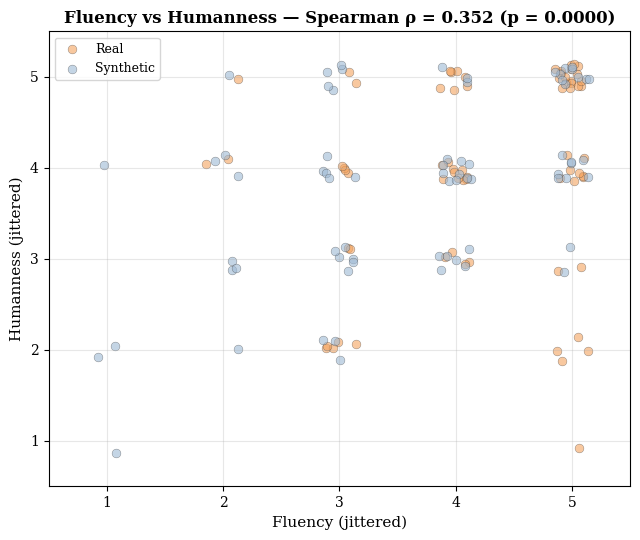

=== Contingency table ===
Low Humanness (<=2)  False  True 
Low Fluency (<=2)                
False                  112     13
True                    11      4 

Chi-square test: chi2=1.972, dof=1, p=0.1602

Of 15 comments with low fluency (<=2), 4 (26.7%) also have low humanness (<=2).
Baseline rate of low humanness overall: 12.1%


In [34]:
from scipy.stats import chi2_contingency

rng = np.random.default_rng(42)
jitter = lambda s: s + rng.uniform(-0.15, 0.15, size=len(s))

rho, p = spearmanr(results['fluency'], results['humanness'])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for cond in conditions:
    sub = results[results['condition'] == cond]
    ax.scatter(jitter(sub['fluency']), jitter(sub['humanness']),
               color=cond_colors[cond], alpha=0.6, s=40,
               edgecolors='#333333', linewidths=0.3, label=cond.capitalize())

ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_xlabel("Fluency (jittered)", fontsize=11)
ax.set_ylabel("Humanness (jittered)", fontsize=11)
ax.set_title(f"Fluency vs Humanness — Spearman ρ = {rho:.3f} (p = {p:.4f})",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{results_base}\\fluency_vs_humanness_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Direct hypothesis test: low fluency (<=2) co-occurring with low humanness (<=2) ──
low_fluency  = results['fluency'] <= 2
low_humanness = results['humanness'] <= 2

ct = pd.crosstab(low_fluency, low_humanness,
                  rownames=['Low Fluency (<=2)'], colnames=['Low Humanness (<=2)'])
print("=== Contingency table ===")
print(ct, "\n")

chi2, p_chi, dof, expected = chi2_contingency(ct)
print(f"Chi-square test: chi2={chi2:.3f}, dof={dof}, p={p_chi:.4f}")

n_low_fluency = low_fluency.sum()
n_both        = (low_fluency & low_humanness).sum()
print(f"\nOf {n_low_fluency} comments with low fluency (<=2), "
      f"{n_both} ({n_both / n_low_fluency:.1%}) also have low humanness (<=2).")
print(f"Baseline rate of low humanness overall: {low_humanness.mean():.1%}")

## Step 12 — Correlation Matrices: Annotator A vs Annotator B

Same pairwise Spearman correlation between fluency/relevance/humanness, computed separately for Ann A (first annotator in each overlap pair) and Ann B (second annotator), using the 70 overlap items each rated.

C:\Users\20245179\AppData\Local\Temp\ipykernel_36400\3370862393.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


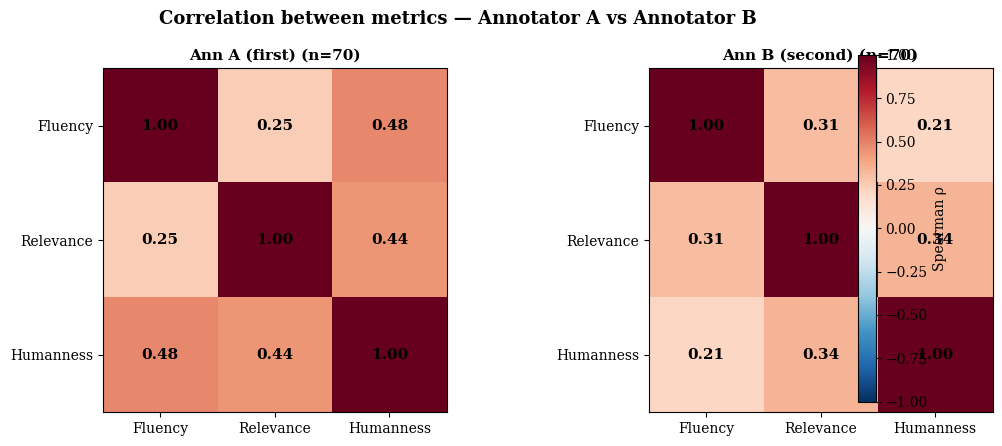


=== Ann A (first) — Spearman correlation (n=70) ===
metric     fluency  relevance  humanness
metric                                  
fluency      1.000      0.247      0.481
relevance    0.247      1.000      0.439
humanness    0.481      0.439      1.000

=== Ann B (second) — Spearman correlation (n=70) ===
metric     fluency  relevance  humanness
metric                                  
fluency      1.000      0.305      0.210
relevance    0.305      1.000      0.336
humanness    0.210      0.336      1.000


In [35]:
# ── Reshape ab_df (long: item_id, condition, metric, ann_label, score) to wide ──
ab_wide = ab_df.pivot_table(index=['item_id', 'ann_label'], columns='metric', values='score').reset_index()

ann_labels = ['Ann A (first)', 'Ann B (second)']
corr_by_ann = {}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, label in zip(axes, ann_labels):
    sub  = ab_wide[ab_wide['ann_label'] == label][metrics]
    corr = sub.corr(method='spearman')
    corr_by_ann[label] = corr

    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels([m.capitalize() for m in metrics])
    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels([m.capitalize() for m in metrics])

    for i in range(len(metrics)):
        for j in range(len(metrics)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha='center', va='center',
                     color='black', fontsize=11, fontweight='bold')

    ax.set_title(f"{label} (n={len(sub)})", fontsize=11, fontweight='bold')

fig.colorbar(im, ax=axes, label="Spearman ρ", fraction=0.046, pad=0.04)
fig.suptitle("Correlation between metrics — Annotator A vs Annotator B", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{results_base}\\metric_correlation_by_annotator.png", dpi=150, bbox_inches='tight')
plt.show()

for label in ann_labels:
    print(f"\n=== {label} — Spearman correlation (n={len(ab_wide[ab_wide['ann_label'] == label])}) ===")
    print(corr_by_ann[label].round(3))